# E2VID — Events-to-Video Reconstruction

**Hybrid Vision · AMI 2026**

This notebook reconstructs intensity frames from raw event-camera data using the **E2VID** recurrent UNet (Rebecq et al., CVPR 2019 / TPAMI 2021).

| Step | What happens |
|------|--------------|
| 1 | Install dependencies |
| 2 | Clone repo + copy model code |
| 3 | Download official pretrained weights |
| 4 | Load event data (FRED sequence **or** synthetic demo) |
| 5 | Run E2VID frame-by-frame |
| 6 | Visualise & save results |

> **Runtime**: set to **GPU** (Runtime → Change runtime type → T4 GPU) for best speed.

---

## 1 — Install dependencies

In [ ]:
#!pip install -q torch torchvision gdown h5py opencv-python-headless huggingface_hub

## 2 — Clone repo & import model

We clone the project repo so we can import the model directly.

In [17]:
import os, sys

REPO = "/content/AMI-KK"

if not os.path.exists(REPO):
    !git clone --depth 1 https://github.com/Dark-Fantasy-K/AMI-KK.git {REPO}
else:
    print("Repo already cloned.")

# Add repo root to Python path so we can import models/
if REPO not in sys.path:
    sys.path.insert(0, REPO)

print("Repo root on sys.path:", REPO)

Repo already cloned.
Repo root on sys.path: /content/AMI-KK


In [18]:
import torch
from models.reconstruction.e2vid.model import E2VID, load_e2vid
from models.reconstruction.utils import (
    load_events_for_sequence,
    events_to_voxel,
    load_frame_timestamps,
    get_frame_size,
    save_frame,
    find_test_sequences,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 3 — Download pretrained E2VID weights

Official checkpoint from [rpg_e2vid](https://github.com/uzh-rpg/rpg_e2vid) (Google Drive).

In [22]:
from google.colab import drive
drive.mount('/content/drive')
E2VID_WEIGHTS = "/content/AMI-KK/models/reconstruction/e2vid/E2VID_lightweight.pth.tar"
import shutil
shutil.copy(
    '/content/drive/MyDrive/ColabNotebooks/E2VID_lightweight.pth.tar',
    '/content/AMI-KK/models/reconstruction/e2vid/'
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


'/content/AMI-KK/models/reconstruction/e2vid/E2VID_lightweight.pth.tar'

Weights already present: /content/AMI-KK/models/reconstruction/e2vid/E2VID_lightweight.pth.tar


In [27]:
model = load_e2vid(E2VID_WEIGHTS, DEVICE)
print("Model loaded:", type(model).__name__)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}  (~{total_params/1e6:.1f} M)")

Model loaded: E2VID
Parameters: 10,710,401  (~10.7 M)


## 4 — Load event data

Two options:

**A.** Download a FRED test sequence via HuggingFace (real drone flight data).  
**B.** Generate synthetic events locally (quick demo, no download needed).

Set `USE_SYNTHETIC = False` to use real FRED data (requires HuggingFace token for gated datasets).  
Set `USE_SYNTHETIC = True` to skip the download and run on generated events.

In [28]:
USE_SYNTHETIC = True   # ← set False to download real FRED sequence

### 4-A  Download one FRED test sequence (real data)

In [29]:
if not USE_SYNTHETIC:
    # ---------------------------------------------------------------------------
    # Download a single FRED test sequence from HuggingFace
    # FRED repo: GabrieleMagrini/FRED  (may require HF login for gated datasets)
    # ---------------------------------------------------------------------------
    from huggingface_hub import hf_hub_download, login
    import zipfile, shutil

    # If the dataset is gated, uncomment and paste your HF token:
    # login(token="hf_YOUR_TOKEN_HERE")

    FRED_ROOT = Path("/content/FRED")
    FRED_ROOT.mkdir(exist_ok=True)

    # Sequence 100 is the first test sequence (sequences 0-99 are train)
    SEQ_FILE = "sequence_100.zip"
    SEQ_NAME = "seq_100"

    print(f"Downloading {SEQ_FILE} from HuggingFace …")
    zip_path = hf_hub_download(
        repo_id="GabrieleMagrini/FRED",
        filename=SEQ_FILE,
        repo_type="dataset",
        local_dir="/content/hf_cache",
    )

    extract_dir = FRED_ROOT / "test" / "sequences" / SEQ_NAME
    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(extract_dir)

    print(f"Extracted to: {extract_dir}")
    print("Contents:", list(extract_dir.iterdir()))
    SEQ_DIR = extract_dir
else:
    print("Skipping FRED download — will use synthetic events in section 4-B.")

Skipping FRED download — will use synthetic events in section 4-B.


### 4-B  Generate synthetic events (demo mode)

In [32]:
import numpy as np
from pathlib import Path

if USE_SYNTHETIC:
    # -------------------------------------------------------------------------
    # Simulate a moving bright spot (drone-like blob) across N frames.
    # Events are generated where the blob boundary crosses pixels.
    # -------------------------------------------------------------------------
    RNG = np.random.default_rng(42)

    H, W      = 160, 224          # sensor resolution
    N_FRAMES  = 20                # number of reconstructed frames to produce
    FPS       = 30.0
    NUM_BINS  = 5

    # Build a reference intensity scene (background gradient + moving blob)
    def make_scene(frame_idx: int, n_frames: int) -> np.ndarray:
        """Return (H, W) float32 intensity in [0, 1]."""
        img = np.zeros((H, W), dtype=np.float32)
        # Smooth background gradient
        img += np.linspace(0.05, 0.25, W)[None, :]
        # Moving bright ellipse (simulated drone)
        t = frame_idx / max(n_frames - 1, 1)
        cx = int(W * (0.2 + 0.6 * t))
        cy = int(H * (0.5 + 0.15 * np.sin(2 * np.pi * t)))
        yy, xx = np.ogrid[:H, :W]
        mask = ((xx - cx) / 18) ** 2 + ((yy - cy) / 10) ** 2 < 1
        img[mask] = 0.90
        return img

    # Generate events between consecutive frames
    scenes     = [make_scene(i, N_FRAMES + 1) for i in range(N_FRAMES + 1)]
    LOG_THR    = 0.03             # log-intensity change threshold

    all_x, all_y, all_t, all_p = [], [], [], []
    timestamps = []
    rgb_frames  = []              # store synthetic "RGB" frames for display

    log_scene_prev = np.log(np.clip(scenes[0], 1e-4, None))

    for i in range(1, N_FRAMES + 1):
        t0 = (i - 1) / FPS
        t1 = i       / FPS
        timestamps.append(t1)

        log_scene_curr = np.log(np.clip(scenes[i], 1e-4, None))
        diff = log_scene_curr - log_scene_prev

        pos_y, pos_x = np.where(diff >  LOG_THR)
        neg_y, neg_x = np.where(diff < -LOG_THR)

        def _emit(ys, xs, pol):
            n = len(xs)
            if n == 0:
                return
            ts = RNG.uniform(t0, t1, n)
            all_x.extend(xs.tolist())
            all_y.extend(ys.tolist())
            all_t.extend(ts.tolist())
            all_p.extend([pol] * n)

        _emit(pos_y, pos_x, 1)
        _emit(neg_y, neg_x, 0)

        log_scene_prev = log_scene_curr
        rgb_frames.append((scenes[i] * 255).astype(np.uint8))

    EVENTS = {
        "x": np.array(all_x, dtype=np.int32),
        "y": np.array(all_y, dtype=np.int32),
        "t": np.array(all_t, dtype=np.float64),
        "p": np.array(all_p, dtype=np.int8),
    }
    TIMESTAMPS = np.array(timestamps, dtype=np.float64)

    print(f"Synthetic dataset ready")
    print(f"  Resolution : {H} × {W}")
    print(f"  Frames     : {N_FRAMES}")
    print(f"  Events     : {len(EVENTS['x']):,}")
else:
    # Real FRED sequence — will be read in section 5.
    EVENTS     = None
    TIMESTAMPS = None
    rgb_frames = []

Synthetic dataset ready
  Resolution : 160 × 224
  Frames     : 20
  Events     : 8,762


## 5 — Run E2VID reconstruction

In [33]:
import cv2

OUTPUT_DIR = Path("/content/reconstructed")
OUTPUT_DIR.mkdir(exist_ok=True)

reconstructed_frames = []   # list of (H, W) float32 in [0, 1]


def reconstruct_from_events(
    events: dict,
    timestamps: np.ndarray,
    height: int,
    width: int,
    num_bins: int = 5,
) -> list:
    """Run E2VID on a sequence of voxel grids.  Returns list of (H,W) float32."""
    frames_out = []
    model.reset_states()

    for i, t_end in enumerate(timestamps):
        t_start = timestamps[i - 1] if i > 0 else t_end - 1.0 / 30.0

        voxel = events_to_voxel(events, height, width, num_bins, t_start, t_end)
        voxel_t = torch.from_numpy(voxel).unsqueeze(0).to(DEVICE)  # (1, B, H, W)

        with torch.inference_mode():
            recon = model(voxel_t)           # (1, 1, H, W)

        recon_np = recon[0, 0].cpu().numpy().astype(np.float32)
        frames_out.append(recon_np)

        if (i + 1) % 5 == 0:
            print(f"  Frame {i+1:3d}/{len(timestamps)}", end="\r")

    print(f"  Done: {len(frames_out)} frames reconstructed.")
    return frames_out


# --------------------------------------------------------------------------
if USE_SYNTHETIC:
    print("Running E2VID on synthetic events …")
    reconstructed_frames = reconstruct_from_events(
        EVENTS, TIMESTAMPS, H, W, num_bins=NUM_BINS
    )
else:
    # FRED real sequence
    print("Loading events from FRED sequence …")
    EVENTS     = load_events_for_sequence(SEQ_DIR)
    H, W       = get_frame_size(SEQ_DIR)
    TIMESTAMPS = load_frame_timestamps(SEQ_DIR)
    NUM_BINS   = 5

    print(f"Sequence: {SEQ_DIR.name}  |  {H}×{W}  |  {len(TIMESTAMPS)} frames  |  {len(EVENTS['x']):,} events")
    print("Running E2VID …")
    reconstructed_frames = reconstruct_from_events(
        EVENTS, TIMESTAMPS, H, W, num_bins=NUM_BINS
    )

    # Also collect RGB frames for side-by-side display
    rgb_frames = []
    for p in sorted((SEQ_DIR / "rgb").glob("*.jpg")) + sorted((SEQ_DIR / "rgb").glob("*.png")):
        img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            rgb_frames.append(img)

# Save all reconstructed frames as PNG
for i, frame in enumerate(reconstructed_frames):
    out_path = OUTPUT_DIR / f"{i+1:06d}.png"
    save_frame(frame, out_path)

print(f"Saved {len(reconstructed_frames)} frames → {OUTPUT_DIR}")

Running E2VID on synthetic events …
  Done: 20 frames reconstructed.
Saved 20 frames → /content/reconstructed


## 6 — Visualise results

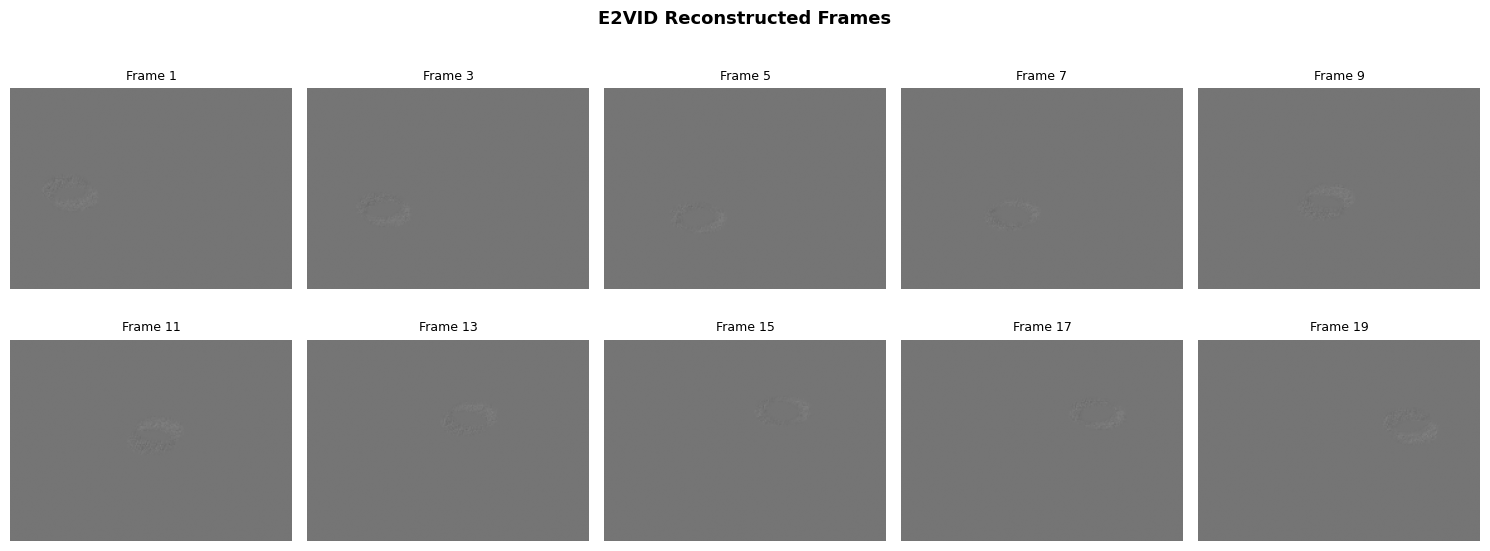

In [34]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Show a grid of reconstructed frames
N_SHOW = min(10, len(reconstructed_frames))
cols   = 5
rows   = (N_SHOW + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3))
axes = np.array(axes).flatten()

step = max(1, len(reconstructed_frames) // N_SHOW)
indices = list(range(0, len(reconstructed_frames), step))[:N_SHOW]

for j, idx in enumerate(indices):
    axes[j].imshow(reconstructed_frames[idx], cmap="gray", vmin=0, vmax=1)
    axes[j].set_title(f"Frame {idx+1}", fontsize=9)
    axes[j].axis("off")

for ax in axes[len(indices):]:
    ax.axis("off")

fig.suptitle("E2VID Reconstructed Frames", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

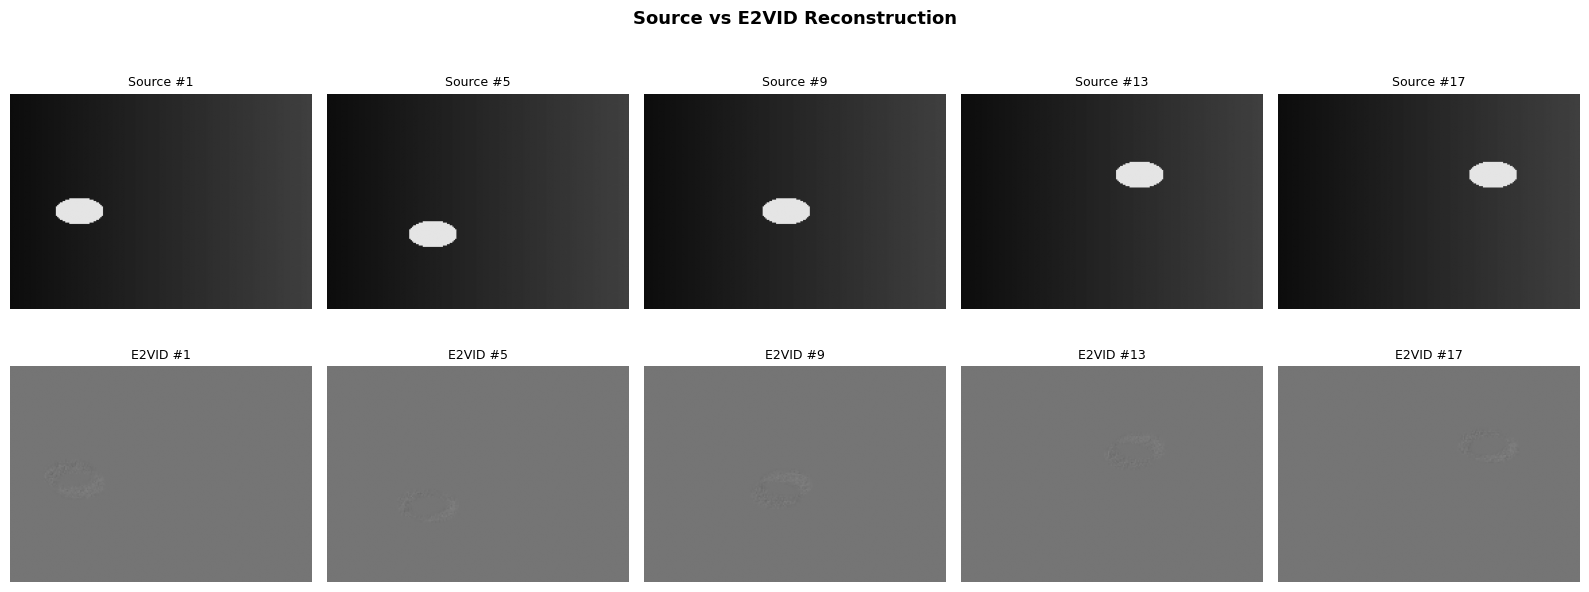

In [35]:
# Side-by-side: original intensity (RGB/synthetic) vs E2VID reconstruction
N_PAIRS = min(5, len(reconstructed_frames), len(rgb_frames))

if N_PAIRS > 0:
    fig, axes = plt.subplots(2, N_PAIRS, figsize=(N_PAIRS * 3.2, 6.5))

    step = max(1, len(reconstructed_frames) // N_PAIRS)
    indices = list(range(0, len(reconstructed_frames), step))[:N_PAIRS]

    for col, idx in enumerate(indices):
        # Top row: source (RGB or synthetic ground truth)
        src = rgb_frames[idx] if idx < len(rgb_frames) else np.zeros((H, W), np.uint8)
        if src.ndim == 3:                          # BGR → gray for display
            src = cv2.cvtColor(src, cv2.COLOR_BGR2GRAY)
        axes[0, col].imshow(src, cmap="gray", vmin=0, vmax=255)
        axes[0, col].set_title(f"Source #{idx+1}", fontsize=9)
        axes[0, col].axis("off")

        # Bottom row: E2VID reconstruction
        axes[1, col].imshow(reconstructed_frames[idx], cmap="gray", vmin=0, vmax=1)
        axes[1, col].set_title(f"E2VID #{idx+1}", fontsize=9)
        axes[1, col].axis("off")

    axes[0, 0].set_ylabel("Source", fontsize=10, labelpad=6)
    axes[1, 0].set_ylabel("E2VID", fontsize=10, labelpad=6)

    fig.suptitle("Source vs E2VID Reconstruction", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("No source frames available for comparison (run section 4 first).")

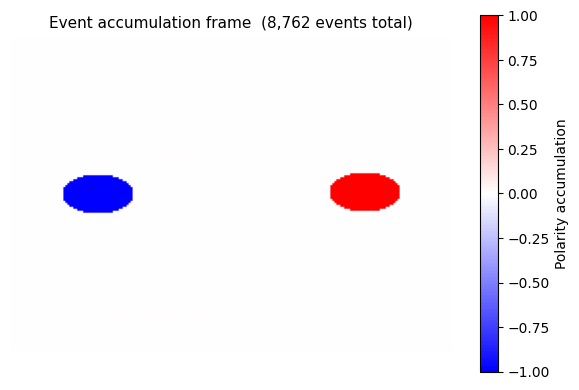

In [36]:
# Event accumulation frame (sum of positive / negative events over all timestamps)
# Useful to sanity-check that events look reasonable.
evt_frame = np.zeros((H, W), dtype=np.float32)
pol_signed = EVENTS["p"].astype(np.float32) * 2 - 1   # {0,1} → {-1,+1}

xs = np.clip(EVENTS["x"], 0, W - 1)
ys = np.clip(EVENTS["y"], 0, H - 1)
np.add.at(evt_frame, (ys, xs), pol_signed)

# Symmetric normalise to [-1, 1]
m = np.abs(evt_frame).max()
if m > 0:
    evt_frame /= m

plt.figure(figsize=(6, 4))
plt.imshow(evt_frame, cmap="bwr", vmin=-1, vmax=1)
plt.colorbar(label="Polarity accumulation")
plt.title(f"Event accumulation frame  ({len(EVENTS['x']):,} events total)", fontsize=11)
plt.axis("off")
plt.tight_layout()
plt.show()

## 7 — Save as video (optional)

In [37]:
VIDEO_PATH = "/content/e2vid_reconstruction.mp4"

if reconstructed_frames:
    fH, fW = reconstructed_frames[0].shape
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    writer = cv2.VideoWriter(VIDEO_PATH, fourcc, 30.0, (fW, fH))

    for frame in reconstructed_frames:
        gray_u8 = np.clip(frame * 255, 0, 255).astype(np.uint8)
        bgr     = cv2.cvtColor(gray_u8, cv2.COLOR_GRAY2BGR)
        writer.write(bgr)

    writer.release()
    print(f"Video saved → {VIDEO_PATH}")

    # Play inline in Colab
    from IPython.display import HTML
    from base64 import b64encode

    mp4 = open(VIDEO_PATH, "rb").read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    HTML(f"""<video width="{fW}" height="{fH}" controls>
               <source src="{data_url}" type="video/mp4">
             </video>""")
else:
    print("No frames to write.")

Video saved → /content/e2vid_reconstruction.mp4


## 8 — Upload your own event file (optional)

You can drop any `.npy` or `.h5` event file below and run reconstruction on it.

In [ ]:
from google.colab import files as colab_files

print("Upload an events file (.npy structured array with fields x,y,t,p  OR  4-column array;  or .h5 with datasets x,y,t,p)")
uploaded = colab_files.upload()   # opens a file picker

if uploaded:
    import io, tempfile

    fname = next(iter(uploaded))
    data  = uploaded[fname]

    # Write to tmp and load
    tmp = Path(f"/content/uploaded_{fname}")
    tmp.write_bytes(data)

    if fname.endswith(".npy"):
        from models.reconstruction.utils import _load_npy as _ln
        custom_events = _ln(tmp)
    elif fname.endswith((".h5", ".hdf5")):
        from models.reconstruction.utils import _load_h5 as _lh
        custom_events = _lh(tmp)
    else:
        raise ValueError(f"Unsupported format: {fname}")

    print(f"Loaded {len(custom_events['x']):,} events from {fname}")

    # Infer sensor resolution from max coords
    cH = int(custom_events["y"].max()) + 1
    cW = int(custom_events["x"].max()) + 1
    print(f"Inferred resolution: {cH}×{cW}")

    # Build uniform timestamps across the full time range
    t_min, t_max = custom_events["t"].min(), custom_events["t"].max()
    cN_FRAMES = 20
    cTS = np.linspace(t_min, t_max, cN_FRAMES + 1)[1:]   # exclude t_min

    model.reset_states()
    print(f"Reconstructing {cN_FRAMES} frames from uploaded events …")
    custom_recon = reconstruct_from_events(custom_events, cTS, cH, cW)

    # Quick display
    n_show = min(5, len(custom_recon))
    fig, axes = plt.subplots(1, n_show, figsize=(n_show * 3, 3))
    for j in range(n_show):
        axes[j].imshow(custom_recon[j * len(custom_recon) // n_show], cmap="gray", vmin=0, vmax=1)
        axes[j].axis("off")
    fig.suptitle(f"E2VID — {fname}", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("No file uploaded — skipping.")

Upload an events file (.npy structured array with fields x,y,t,p  OR  4-column array;  or .h5 with datasets x,y,t,p)


---

## Notes

| Parameter | Default | Effect |
|-----------|---------|--------|
| `NUM_BINS` | 5 | Voxel grid time bins — must match checkpoint (5 for official E2VID) |
| `USE_SYNTHETIC` | `True` | Switch to `False` + set HF token to use real FRED data |
| `model.reset_states()` | — | Call between independent sequences to clear LSTM hidden states |

**References**
- Rebecq et al., *Events-to-Video*, CVPR 2019 / TPAMI 2021  
- Official code: https://github.com/uzh-rpg/rpg_e2vid  
- FRED dataset: https://miccunifi.github.io/FRED/